# 从 BPR 到合法 Semantic ID：生成式推荐 Hands-on

这是一份与 Huiyu Chen 的「20 篇论文读懂生成式推荐」系列配套的、
可从头运行的教学 notebook。它不是某一篇论文的逐行复现，而是把系列中
最关键的接口串成一条可修改的最小链路：

**隐式反馈 → BPR 商品向量 → Residual Quantization → Semantic ID
→ 自回归生成 → Trie 约束 → 有效性评测**

<a href="https://colab.research.google.com/github/chenhuiyu/chenhuiyu.github.io/blob/source/public/notebooks/generative-recommendation-hands-on.ipynb"
   target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg"
       alt="Open in Colab">
</a>

> 教学边界：数据、模型与 codebook 都刻意缩小，方便你修改和理解。
> 完整 TIGER、LETTER、OneRec 或 DIGER 复现仍需要真实序列、训练框架、
> 分布式检索与严格的离线/在线评测。

## Goal

运行完这份 notebook，你应该能回答五个问题：

1. BPR 为什么是一台“打分机”，它学到的 item embedding 能否成为生成模型的输入？
2. Residual Quantization 如何把连续向量变成由粗到细的离散地址？
3. 为什么生成 Semantic ID 与传统 Top-K 打分在计算图上不同？
4. 为什么一个概率很高的 token 序列可能根本不对应目录里的商品？
5. 除了 Recall@K，生成式推荐还必须监控哪些 tokenizer 与解码指标？

### 与博客系列的对应关系

| Notebook 阶段 | 对应文章 | 这里保留的核心思想 |
|---|---|---|
| Pairwise ranking | [01 · BPR](https://chenhuiyu.github.io/blog/generative-recommendation-01-bpr-zh) | 从正负反馈中学习用户与商品向量 |
| Sequence as tokens | [02 · GRU4Rec](https://chenhuiyu.github.io/blog/generative-recommendation-02-gru4rec-zh)、[03 · SASRec](https://chenhuiyu.github.io/blog/generative-recommendation-03-sasrec-zh)、[04 · BERT4Rec](https://chenhuiyu.github.io/blog/generative-recommendation-04-bert4rec-zh) | 用户历史不再只是一个静态特征 |
| Retrieval as generation | [10 · DSI](https://chenhuiyu.github.io/blog/generative-recommendation-10-dsi-zh) | 检索目标可以被写成 token |
| Semantic tokenizer | [11 · TIGER](https://chenhuiyu.github.io/blog/generative-recommendation-11-tiger-zh)、[13 · LC-Rec](https://chenhuiyu.github.io/blog/generative-recommendation-13-lc-rec-zh)、[14 · LETTER](https://chenhuiyu.github.io/blog/generative-recommendation-14-letter-zh) | ID 需要同时考虑内容、协同信号与均衡 |
| Joint optimization | [15 · ETEGRec](https://chenhuiyu.github.io/blog/generative-recommendation-15-etegrec-zh)、[2026 · DIGER](https://chenhuiyu.github.io/blog/generative-recommendation-2026-01-diger-zh) | tokenizer 不应永远停留在离线预处理 |
| Unified generation | [17 · OneRec](https://chenhuiyu.github.io/blog/generative-recommendation-17-onerec-zh) | 召回与排序可以共享同一生成目标 |
| Failure audit | [2026 · CARE](https://chenhuiyu.github.io/blog/generative-recommendation-2026-02-care-zh)、[2026 · 泛化审计](https://chenhuiyu.github.io/blog/generative-recommendation-2026-07-generalization-zh) | 深层误差、非法 ID 与泛化需要单独测量 |

## Setup

默认参数都集中在下面这个 cell。建议第一次完整运行后，只改一个变量，
再观察后面的图与检查项怎样变化。

In [1]:
from collections import Counter
from math import exp, log

import matplotlib.pyplot as plt
import numpy as np

SEED = 7
EMBEDDING_DIM = 6
BPR_EPOCHS = 350
CODEBOOK_SIZE = 4
NUM_CODEBOOKS = 4
TEMPERATURE = 0.8
BEAM_WIDTH = 16
SMOOTHING = 0.35

rng = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)

print("Parameters")
print({
    "embedding_dim": EMBEDDING_DIM,
    "bpr_epochs": BPR_EPOCHS,
    "semantic_id_shape": f"{NUM_CODEBOOKS} × {CODEBOOK_SIZE}",
    "temperature": TEMPERATURE,
    "beam_width": BEAM_WIDTH,
})

Parameters
{'embedding_dim': 6, 'bpr_epochs': 350, 'semantic_id_shape': '4 × 4', 'temperature': 0.8, 'beam_width': 16}


## Steps

### 1. 建一个小型隐式反馈数据集

我们用 12 件运动商品和 8 条用户历史。每条历史的最后一件商品留作
next-item 检查，其余点击用于训练 BPR。真实系统会有曝光偏差、时间窗口、
多行为权重与数百万商品；这里先把这些变量拿掉。

24 training interactions; 8 next-item holdouts


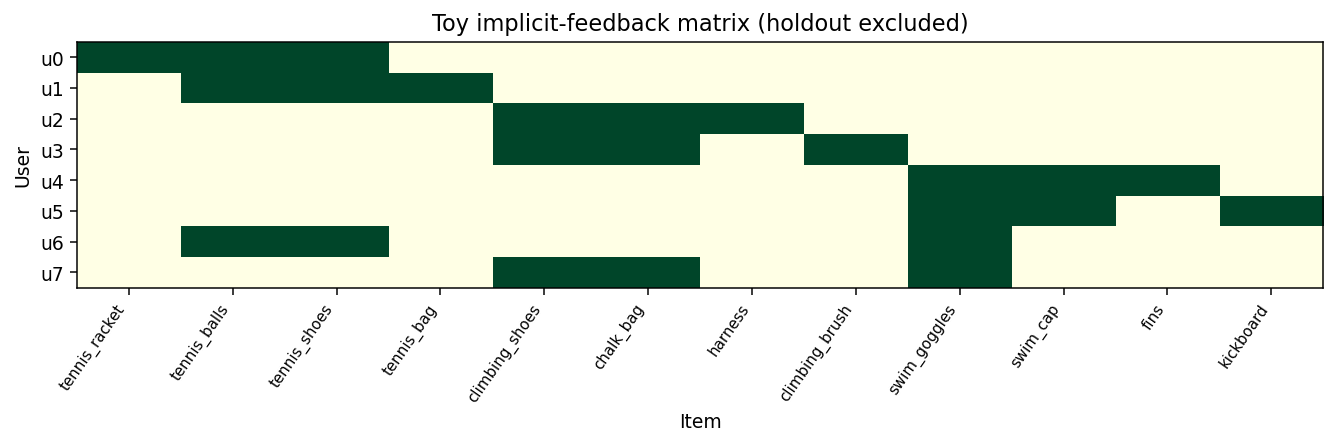

In [2]:
item_names = [
    "tennis_racket", "tennis_balls", "tennis_shoes", "tennis_bag",
    "climbing_shoes", "chalk_bag", "harness", "climbing_brush",
    "swim_goggles", "swim_cap", "fins", "kickboard",
]
item_group = {
    name: ("tennis" if index < 4 else "climbing" if index < 8 else "swim")
    for index, name in enumerate(item_names)
}
item_to_index = {name: index for index, name in enumerate(item_names)}

histories = {
    "u0": ["tennis_balls", "tennis_racket", "tennis_shoes", "tennis_bag"],
    "u1": ["tennis_shoes", "tennis_balls", "tennis_bag", "tennis_racket"],
    "u2": ["chalk_bag", "climbing_shoes", "harness", "climbing_brush"],
    "u3": ["climbing_brush", "chalk_bag", "climbing_shoes", "harness"],
    "u4": ["swim_cap", "swim_goggles", "fins", "kickboard"],
    "u5": ["kickboard", "swim_goggles", "swim_cap", "fins"],
    "u6": ["tennis_balls", "tennis_shoes", "swim_goggles", "swim_cap"],
    "u7": ["chalk_bag", "climbing_shoes", "swim_goggles", "fins"],
}
user_names = list(histories)
train_items = {
    user: [item_to_index[name] for name in sequence[:-1]]
    for user, sequence in histories.items()
}
holdout_items = {
    user: item_to_index[sequence[-1]]
    for user, sequence in histories.items()
}

interaction = np.zeros((len(user_names), len(item_names)))
for user_index, user in enumerate(user_names):
    interaction[user_index, train_items[user]] = 1

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.imshow(interaction, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set(
    title="Toy implicit-feedback matrix (holdout excluded)",
    xlabel="Item",
    ylabel="User",
    xticks=range(len(item_names)),
    yticks=range(len(user_names)),
)
ax.set_xticklabels(item_names, rotation=55, ha="right", fontsize=8)
ax.set_yticklabels(user_names)
fig.tight_layout()
plt.show()

print(f"{interaction.sum():.0f} training interactions; "
      f"{len(holdout_items)} next-item holdouts")

### 2. 用 BPR 学习连续商品向量

对用户 \(u\)、正样本 \(i\) 与未交互商品 \(j\)，BPR 优化：

\[
-\log \sigma(s(u,i)-s(u,j)) + \lambda \lVert\Theta\rVert_2^2
\]

它关心的是“正样本比分到的负样本高”，并不会生成商品。这里保留它，
是为了让 Semantic ID 的连续向量来自推荐信号，而不是随手画几个点。

loss: 0.6866 → 0.0075


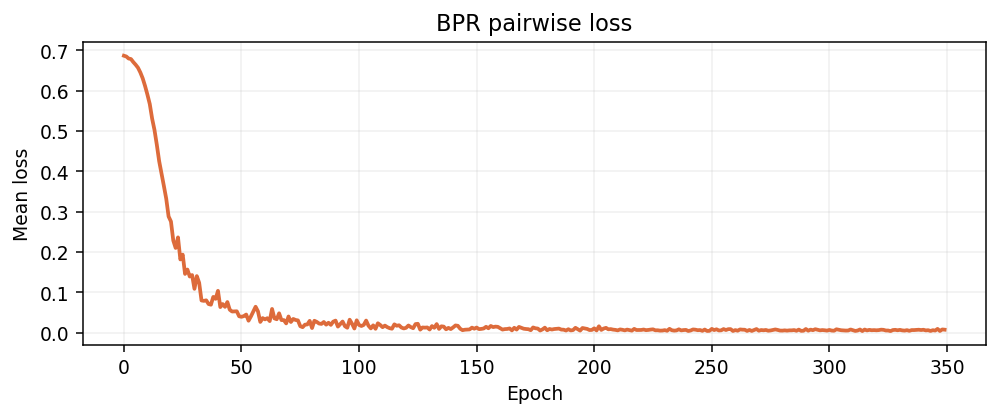

In [3]:
number_of_users = len(user_names)
number_of_items = len(item_names)
user_embeddings = rng.normal(0, 0.12, (number_of_users, EMBEDDING_DIM))
item_embeddings = rng.normal(0, 0.12, (number_of_items, EMBEDDING_DIM))

learning_rate = 0.045
regularization = 0.003
loss_history = []

for epoch in range(BPR_EPOCHS):
    epoch_losses = []
    for user_index, user in enumerate(user_names):
        positives = set(train_items[user])
        negatives = [index for index in range(number_of_items)
                     if index not in positives]
        for positive_index in sorted(positives):
            for _ in range(2):
                negative_index = int(rng.choice(negatives))
                user_vector = user_embeddings[user_index].copy()
                positive_vector = item_embeddings[positive_index].copy()
                negative_vector = item_embeddings[negative_index].copy()

                margin = float(
                    user_vector @ (positive_vector - negative_vector)
                )
                margin = float(np.clip(margin, -20, 20))
                sigmoid = 1.0 / (1.0 + np.exp(-margin))
                gradient_weight = 1.0 - sigmoid
                epoch_losses.append(-np.log(sigmoid + 1e-12))

                user_embeddings[user_index] += learning_rate * (
                    gradient_weight * (positive_vector - negative_vector)
                    - regularization * user_vector
                )
                item_embeddings[positive_index] += learning_rate * (
                    gradient_weight * user_vector
                    - regularization * positive_vector
                )
                item_embeddings[negative_index] += learning_rate * (
                    -gradient_weight * user_vector
                    - regularization * negative_vector
                )
    loss_history.append(float(np.mean(epoch_losses)))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(loss_history, color="#dd6b3b", linewidth=2)
ax.set(
    title="BPR pairwise loss",
    xlabel="Epoch",
    ylabel="Mean loss",
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"loss: {loss_history[0]:.4f} → {loss_history[-1]:.4f}")

In [4]:
# A tiny next-item check: rank every unseen item for each user.
hits = 0
for user_index, user in enumerate(user_names):
    scores = user_embeddings[user_index] @ item_embeddings.T
    scores[list(set(train_items[user]))] = -np.inf
    top3 = np.argsort(scores)[-3:][::-1]
    target = holdout_items[user]
    hits += int(target in top3)
    print(
        f"{user}: target={item_names[target]:<16} "
        f"top3={[item_names[index] for index in top3]}"
    )

recall_at_3 = hits / len(user_names)
print(f"\nToy BPR Recall@3 = {recall_at_3:.3f}")

u0: target=tennis_bag       top3=['tennis_bag', 'swim_goggles', 'harness']
u1: target=tennis_racket    top3=['tennis_racket', 'kickboard', 'fins']
u2: target=climbing_brush   top3=['climbing_brush', 'kickboard', 'tennis_racket']
u3: target=harness          top3=['harness', 'fins', 'tennis_racket']
u4: target=kickboard        top3=['kickboard', 'climbing_brush', 'tennis_shoes']
u5: target=fins             top3=['fins', 'harness', 'tennis_balls']
u6: target=swim_cap         top3=['tennis_racket', 'swim_cap', 'kickboard']
u7: target=fins             top3=['harness', 'climbing_brush', 'swim_cap']

Toy BPR Recall@3 = 0.875


### 3. 看商品向量是否形成了可量化的结构

下图只是把六维 embedding 用 SVD 投影到二维。相邻不等于业务上“完全相似”；
它表示在这个 toy 反馈矩阵和 BPR 目标下，模型倾向于给它们相近的方向。

tennis_racket → [('tennis_shoes', 0.539), ('tennis_balls', 0.517), ('harness', 0.083)]
climbing_shoes → [('chalk_bag', 0.999), ('harness', 0.466), ('climbing_brush', 0.444)]
swim_goggles → [('swim_cap', 0.537), ('kickboard', 0.261), ('fins', 0.155)]


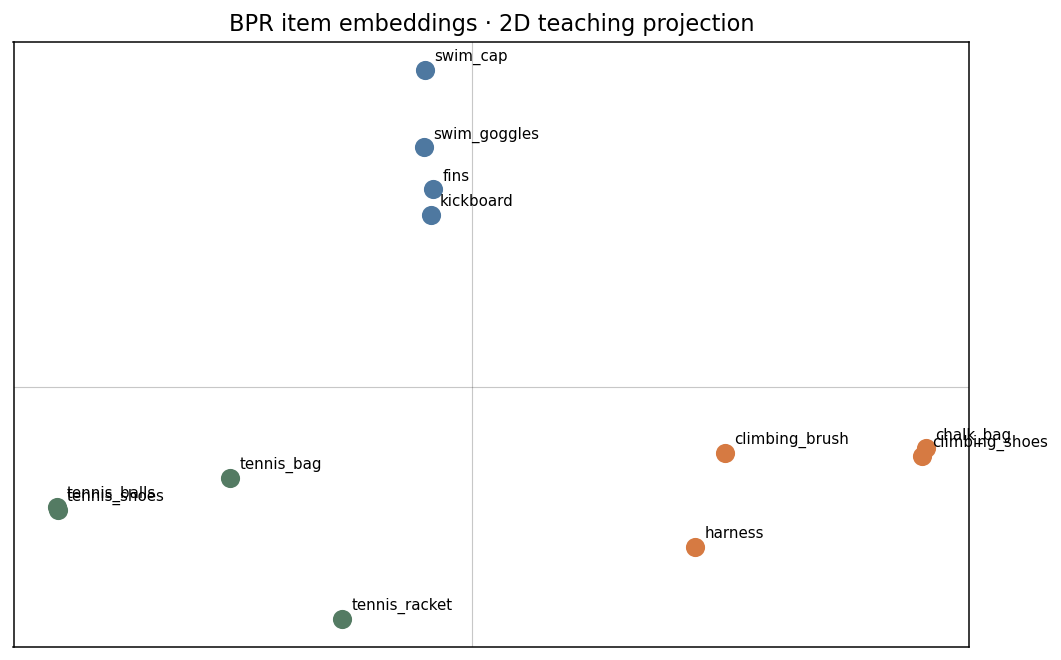

In [5]:
item_norms = np.linalg.norm(item_embeddings, axis=1, keepdims=True)
normalized_items = item_embeddings / np.maximum(item_norms, 1e-12)
centered_items = normalized_items - normalized_items.mean(axis=0)
_, _, right_vectors = np.linalg.svd(centered_items, full_matrices=False)
item_xy = centered_items @ right_vectors[:2].T

group_color = {
    "tennis": "#547b63",
    "climbing": "#d67a42",
    "swim": "#4e78a0",
}
fig, ax = plt.subplots(figsize=(8, 5))
for index, name in enumerate(item_names):
    group = item_group[name]
    ax.scatter(*item_xy[index], s=85, color=group_color[group])
    ax.annotate(name, item_xy[index], xytext=(5, 5),
                textcoords="offset points", fontsize=8)
ax.axhline(0, color="#222", linewidth=0.6, alpha=0.25)
ax.axvline(0, color="#222", linewidth=0.6, alpha=0.25)
ax.set(title="BPR item embeddings · 2D teaching projection")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

similarity = normalized_items @ normalized_items.T
for anchor in ("tennis_racket", "climbing_shoes", "swim_goggles"):
    anchor_index = item_to_index[anchor]
    neighbors = np.argsort(similarity[anchor_index])[-4:][::-1]
    print(anchor, "→", [
        (item_names[index], round(float(similarity[anchor_index, index]), 3))
        for index in neighbors if index != anchor_index
    ])

### 4. 用 Residual Quantization 构造 Semantic ID

第 \(m\) 层只量化上一层留下的残差：

\[
q_m=\arg\min_k\lVert r_{m-1}-e_{m,k}\rVert_2^2,\qquad
r_m=r_{m-1}-e_{m,q_m}
\]

四层 codebook 产生一个四 token 地址。前面的 token 粗，后面的 token
负责修正细节。注意：低重构误差、低碰撞率和推荐目标一致性是三件不同的事。

tennis_racket      → (1, 0, 0, 3)
tennis_balls       → (0, 0, 0, 2)
tennis_shoes       → (0, 0, 0, 2)
tennis_bag         → (1, 1, 3, 3)
climbing_shoes     → (3, 3, 0, 3)
chalk_bag          → (3, 3, 0, 3)
harness            → (1, 3, 1, 0)
climbing_brush     → (3, 1, 0, 3)
swim_goggles       → (0, 3, 2, 3)
swim_cap           → (2, 3, 0, 1)
fins               → (2, 0, 1, 3)
kickboard          → (0, 2, 0, 3)


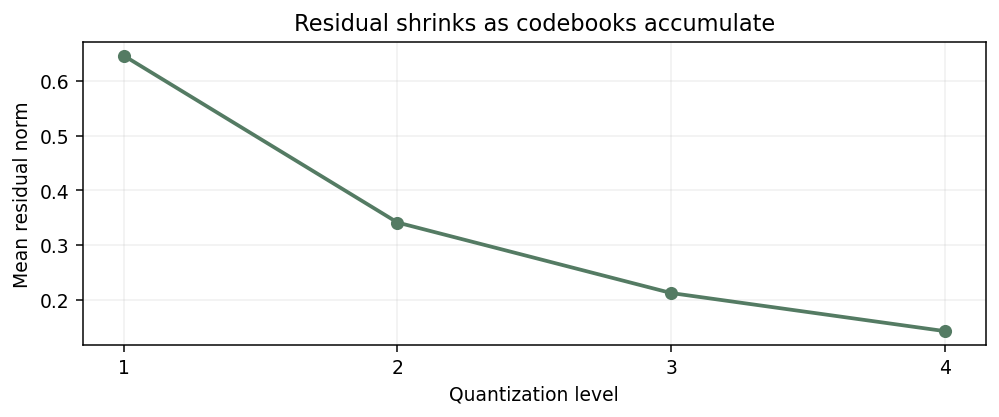

In [6]:
def fit_codebook(vectors, size, seed, iterations=40):
    local_rng = np.random.default_rng(seed)
    centers = vectors[local_rng.choice(
        len(vectors), size=size, replace=False
    )].copy()
    for _ in range(iterations):
        squared_distance = (
            (vectors[:, None, :] - centers[None, :, :]) ** 2
        ).sum(axis=2)
        assignments = squared_distance.argmin(axis=1)
        updated = centers.copy()
        for code_index in range(size):
            members = vectors[assignments == code_index]
            if len(members):
                updated[code_index] = members.mean(axis=0)
        if np.allclose(updated, centers):
            break
        centers = updated
    return centers, assignments


residuals = normalized_items.copy()
reconstruction = np.zeros_like(normalized_items)
codebooks = []
code_columns = []
error_by_level = []

for level in range(NUM_CODEBOOKS):
    codebook, assignments = fit_codebook(
        residuals, CODEBOOK_SIZE, SEED + level
    )
    codebooks.append(codebook)
    code_columns.append(assignments)
    reconstruction += codebook[assignments]
    residuals = normalized_items - reconstruction
    error_by_level.append(
        float(np.mean(np.linalg.norm(residuals, axis=1)))
    )

semantic_ids = [
    tuple(int(column[item_index]) for column in code_columns)
    for item_index in range(number_of_items)
]
catalog = {}
for name, semantic_id in zip(item_names, semantic_ids):
    catalog.setdefault(semantic_id, []).append(name)

for name, semantic_id in zip(item_names, semantic_ids):
    print(f"{name:<18} → {semantic_id}")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(
    range(1, NUM_CODEBOOKS + 1),
    error_by_level,
    marker="o",
    color="#547b63",
    linewidth=2,
)
ax.set(
    title="Residual shrinks as codebooks accumulate",
    xlabel="Quantization level",
    ylabel="Mean residual norm",
    xticks=range(1, NUM_CODEBOOKS + 1),
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [7]:
unique_ids = len(catalog)
collision_rate = 1 - unique_ids / number_of_items
mean_reconstruction_error = float(
    np.mean(np.linalg.norm(normalized_items - reconstruction, axis=1))
)
token_usage = [
    Counter(semantic_id[level] for semantic_id in semantic_ids)
    for level in range(NUM_CODEBOOKS)
]

print(f"unique IDs: {unique_ids}/{number_of_items}")
print(f"collision rate: {collision_rate:.3f}")
print(f"mean reconstruction error: {mean_reconstruction_error:.4f}")
for level, usage in enumerate(token_usage, start=1):
    print(f"L{level} usage:", dict(sorted(usage.items())))

unique IDs: 10/12
collision rate: 0.167
mean reconstruction error: 0.1427
L1 usage: {0: 4, 1: 3, 2: 2, 3: 3}
L2 usage: {0: 4, 1: 2, 2: 1, 3: 5}
L3 usage: {0: 8, 1: 2, 2: 1, 3: 1}
L4 usage: {0: 1, 1: 1, 2: 2, 3: 8}


### 5. 把推荐改写成 token 生成

真实模型会根据用户历史产生每一步 logits。为了把解码问题单独看清，
这里使用一个按位置统计的 toy token model，并加入 smoothing，让模型对
没见过的组合也保留非零概率。这正是非法 Semantic ID 出现的入口：
**每个 token 单看都合理，拼起来却可能不属于任何商品。**

In [8]:
position_counts = []
for level in range(NUM_CODEBOOKS):
    counts = np.full(CODEBOOK_SIZE, SMOOTHING, dtype=float)
    for semantic_id in semantic_ids:
        counts[semantic_id[level]] += 1
    position_counts.append(counts)

valid_ids = set(semantic_ids)

def valid_prefix(prefix):
    return any(
        semantic_id[:len(prefix)] == tuple(prefix)
        for semantic_id in valid_ids
    )

def softmax(logits):
    shifted = logits - np.max(logits)
    weights = np.exp(shifted)
    return weights / weights.sum()

def token_probabilities(level, temperature, allowed_tokens):
    logits = np.log(position_counts[level]) / temperature
    allowed_logits = np.array([logits[token] for token in allowed_tokens])
    probabilities = softmax(allowed_logits)
    return list(zip(allowed_tokens, probabilities))

def beam_search(temperature=TEMPERATURE, beam_width=BEAM_WIDTH,
                trie_constrained=True):
    beams = [((), 0.0)]
    for level in range(NUM_CODEBOOKS):
        candidates = []
        for prefix, log_probability in beams:
            allowed = [
                token for token in range(CODEBOOK_SIZE)
                if not trie_constrained
                or valid_prefix(prefix + (token,))
            ]
            for token, probability in token_probabilities(
                level, temperature, allowed
            ):
                candidates.append((
                    prefix + (token,),
                    log_probability + log(float(probability)),
                ))
        beams = sorted(
            candidates, key=lambda row: row[1], reverse=True
        )[:beam_width]
    return beams

def describe_beams(beams, limit=10):
    rows = []
    for semantic_id, log_probability in beams[:limit]:
        names = catalog.get(semantic_id)
        rows.append({
            "semantic_id": semantic_id,
            "probability": exp(log_probability),
            "status": " · ".join(names) if names else "INVALID ID",
        })
    return rows

unconstrained_beams = beam_search(trie_constrained=False)
constrained_beams = beam_search(trie_constrained=True)

print("UNCONSTRAINED")
for row in describe_beams(unconstrained_beams):
    print(row)
print("\nTRIE CONSTRAINED")
for row in describe_beams(constrained_beams):
    print(row)

UNCONSTRAINED
{'semantic_id': (0, 3, 0, 3), 'probability': 0.07497411692591202, 'status': 'INVALID ID'}
{'semantic_id': (0, 0, 0, 3), 'probability': 0.05788695468798726, 'status': 'INVALID ID'}
{'semantic_id': (1, 3, 0, 3), 'probability': 0.0540886070033116, 'status': 'INVALID ID'}
{'semantic_id': (3, 3, 0, 3), 'probability': 0.0540886070033116, 'status': 'climbing_shoes · chalk_bag'}
{'semantic_id': (1, 0, 0, 3), 'probability': 0.041761408751650506, 'status': 'tennis_racket'}
{'semantic_id': (3, 0, 0, 3), 'probability': 0.041761408751650506, 'status': 'INVALID ID'}
{'semantic_id': (2, 3, 0, 3), 'probability': 0.03472438924461798, 'status': 'INVALID ID'}
{'semantic_id': (0, 1, 0, 3), 'probability': 0.026810441112064924, 'status': 'INVALID ID'}
{'semantic_id': (2, 0, 0, 3), 'probability': 0.026810441112064924, 'status': 'INVALID ID'}
{'semantic_id': (1, 1, 0, 3), 'probability': 0.019341867198368043, 'status': 'INVALID ID'}

TRIE CONSTRAINED
{'semantic_id': (3, 3, 0, 3), 'probability': 0

### 6. 比较同一模型的两种解码结果

Trie 不会让模型“更懂用户”；它做的是目录一致性控制。每一步扩展前，
先屏蔽不可能成为任何商品前缀的 token。于是完整输出的非法率为零，
代价是概率质量会在剩余合法分支上重新归一化。

invalid beams: unconstrained=11/16, Trie=0/10


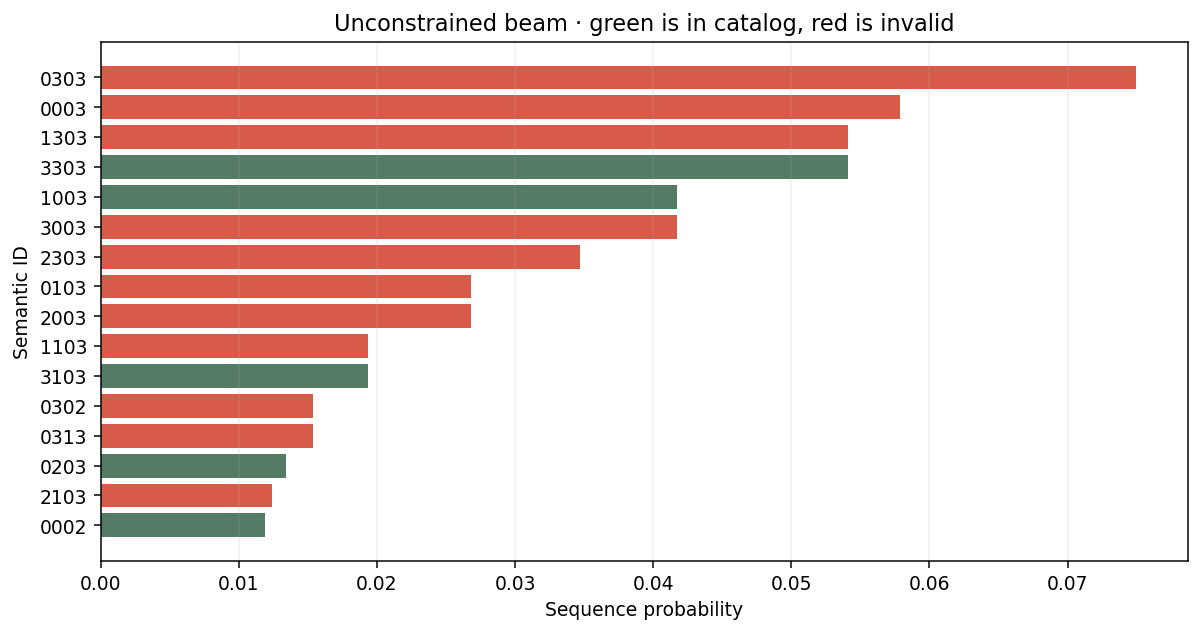

In [9]:
rows = describe_beams(unconstrained_beams, limit=BEAM_WIDTH)
labels = ["".join(map(str, row["semantic_id"])) for row in rows]
probabilities = [row["probability"] for row in rows]
colors = [
    "#547b63" if row["status"] != "INVALID ID" else "#d85b4a"
    for row in rows
]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(rows))
ax.barh(y, probabilities, color=colors)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set(
    title="Unconstrained beam · green is in catalog, red is invalid",
    xlabel="Sequence probability",
    ylabel="Semantic ID",
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

invalid_unconstrained = sum(
    semantic_id not in valid_ids
    for semantic_id, _ in unconstrained_beams
)
invalid_constrained = sum(
    semantic_id not in valid_ids
    for semantic_id, _ in constrained_beams
)
print(
    f"invalid beams: unconstrained={invalid_unconstrained}/{len(unconstrained_beams)}, "
    f"Trie={invalid_constrained}/{len(constrained_beams)}"
)

### 7. 扫描 Temperature：合法率不是一个常数

Temperature 改变分布的尖锐程度。下面不是在证明某个温度“最好”，
而是在示范：生成式推荐的行为指标必须与解码配置一起报告。

T=0.4  invalid=0.769  catalog_coverage=0.900
T=0.6  invalid=0.809  catalog_coverage=1.000
T=0.8  invalid=0.844  catalog_coverage=0.900
T=1.0  invalid=0.873  catalog_coverage=1.000
T=1.3  invalid=0.890  catalog_coverage=1.000
T=1.6  invalid=0.913  catalog_coverage=1.000


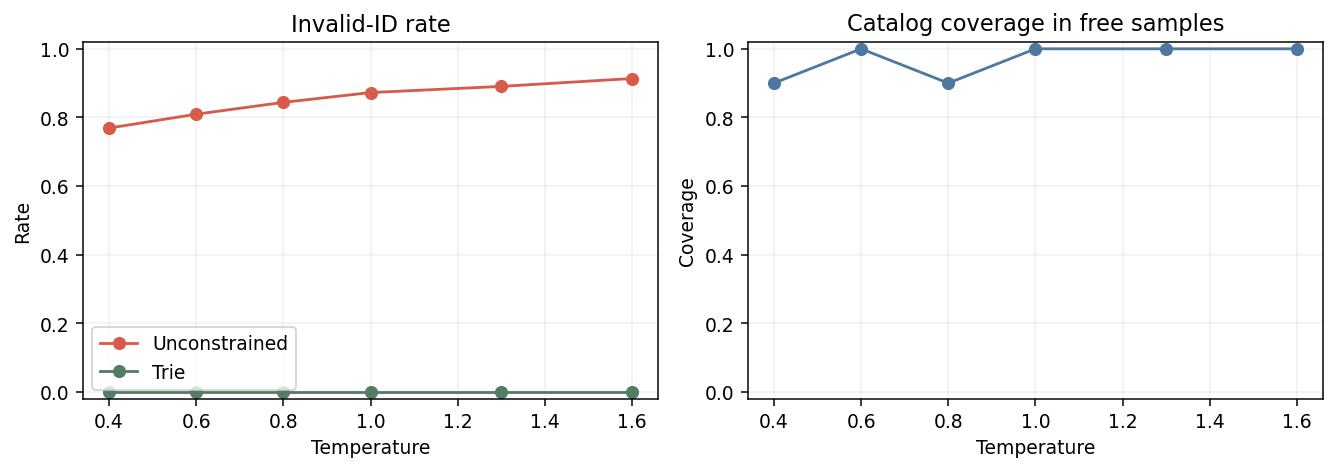

In [10]:
def sample_ids(temperature, trie_constrained, sample_size=2000, seed=0):
    local_rng = np.random.default_rng(seed)
    samples = []
    for _ in range(sample_size):
        prefix = ()
        for level in range(NUM_CODEBOOKS):
            allowed = [
                token for token in range(CODEBOOK_SIZE)
                if not trie_constrained
                or valid_prefix(prefix + (token,))
            ]
            token_rows = token_probabilities(
                level, temperature, allowed
            )
            tokens = [row[0] for row in token_rows]
            probabilities = [row[1] for row in token_rows]
            prefix += (
                int(local_rng.choice(tokens, p=probabilities)),
            )
        samples.append(prefix)
    return samples

temperatures = [0.4, 0.6, 0.8, 1.0, 1.3, 1.6]
free_invalid_rates = []
trie_invalid_rates = []
free_coverages = []

for temperature in temperatures:
    free_samples = sample_ids(
        temperature, False, seed=SEED + int(temperature * 10)
    )
    trie_samples = sample_ids(
        temperature, True, seed=SEED + 100 + int(temperature * 10)
    )
    free_invalid_rates.append(
        np.mean([sample not in valid_ids for sample in free_samples])
    )
    trie_invalid_rates.append(
        np.mean([sample not in valid_ids for sample in trie_samples])
    )
    free_coverages.append(
        len(set(free_samples) & valid_ids) / len(valid_ids)
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(
    temperatures, free_invalid_rates, marker="o",
    color="#d85b4a", label="Unconstrained"
)
axes[0].plot(
    temperatures, trie_invalid_rates, marker="o",
    color="#547b63", label="Trie"
)
axes[0].set(
    title="Invalid-ID rate",
    xlabel="Temperature",
    ylabel="Rate",
    ylim=(-0.02, 1.02),
)
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    temperatures, free_coverages, marker="o", color="#4e78a0"
)
axes[1].set(
    title="Catalog coverage in free samples",
    xlabel="Temperature",
    ylabel="Coverage",
    ylim=(-0.02, 1.02),
)
axes[1].grid(alpha=0.2)
fig.tight_layout()
plt.show()

for temperature, invalid_rate, coverage in zip(
    temperatures, free_invalid_rates, free_coverages
):
    print(
        f"T={temperature:.1f}  invalid={invalid_rate:.3f}  "
        f"catalog_coverage={coverage:.3f}"
    )

## Checks

一个教程 notebook 也应有可失败的检查，而不是只画“看起来合理”的图。
下面验证优化、量化与约束解码的关键不变量。

In [11]:
assert loss_history[-1] < loss_history[0], "BPR loss did not decrease"
assert all(
    len(semantic_id) == NUM_CODEBOOKS for semantic_id in semantic_ids
)
assert error_by_level[-1] <= error_by_level[0]
assert invalid_constrained == 0
assert all(rate == 0 for rate in trie_invalid_rates)
assert invalid_unconstrained > 0, (
    "Increase BEAM_WIDTH to expose invalid combinations"
)

print("✓ BPR optimization moved in the expected direction")
print("✓ every item has a fixed-length Semantic ID")
print("✓ residual quantization reduced reconstruction error")
print("✓ Trie-constrained decoding produced no invalid ID")
print("✓ unconstrained decoding exposed catalog inconsistency")

✓ BPR optimization moved in the expected direction
✓ every item has a fixed-length Semantic ID
✓ residual quantization reduced reconstruction error
✓ Trie-constrained decoding produced no invalid ID
✓ unconstrained decoding exposed catalog inconsistency


## Next Steps

建议按下面顺序改，每次只改一项并重新运行全部 cells：

1. **先动解码**：把 `TEMPERATURE` 改成 0.4 / 1.4，把 `BEAM_WIDTH`
   改成 4 / 32。对应 CARE 对深层偏差的讨论。
2. **再动 tokenizer**：把 `CODEBOOK_SIZE` 改成 3 或 6，
   `NUM_CODEBOOKS` 改成 2 或 5。记录重构误差、碰撞率、token 使用率。
   这对应 TIGER、LC-Rec 与 LETTER 的差异。
3. **替换商品向量**：把 BPR embedding 换成内容 encoder 或序列模型输出，
   对应 LLaRA、HSTU 与 ContRec。
4. **联合优化**：让推荐损失反向影响 codebook，而不是离线固定，
   对应 ETEGRec 与 DIGER。
5. **做真正的推荐评测**：加入用户条件的 decoder，报告 Recall/NDCG、
   invalid-ID rate、catalog coverage、head/tail 分桶与 unseen-item 泛化。

当你把第 5 步补齐，这个教学实验才开始接近一份可比较的论文复现。